training baseline cnn on the imbalanced dataset

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [3]:
PROJECT_ROOT = Path.cwd().parent

IMAGE_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "archive"
    / "classification"
    / "images"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Images exist:", IMAGE_DIR.exists())
print("Processed folder exists:", PROCESSED_DIR.exists())

Images exist: True
Processed folder exists: True


In [4]:
train_df = pd.read_csv(PROCESSED_DIR / "train_split.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val_split.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test_split.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1134
Validation: 243
Test: 243


In [5]:
print("Train classes:")
print(train_df["class_name"].value_counts())

print("\nValidation classes:")
print(val_df["class_name"].value_counts())

print("\nTest classes:")
print(test_df["class_name"].value_counts())

Train classes:
class_name
Surface_Crack    1001
Pinhole           118
Delamination       15
Name: count, dtype: int64

Validation classes:
class_name
Surface_Crack    215
Pinhole           25
Delamination       3
Name: count, dtype: int64

Test classes:
class_name
Surface_Crack    214
Pinhole           26
Delamination       3
Name: count, dtype: int64


three classes converted into numeric label for pytoech

In [6]:
class_names = [
    "Surface_Crack",
    "Pinhole",
    "Delamination"
]

class_to_id = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

class_to_id

{'Surface_Crack': 0, 'Pinhole': 1, 'Delamination': 2}

In [7]:
class CoatingDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = self.image_dir / row["file_name"]
        image = Image.open(image_path).convert("RGB")

        label = class_to_id[row["class_name"]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = CoatingDataset(
    train_df,
    IMAGE_DIR,
    transform
)

val_dataset = CoatingDataset(
    val_df,
    IMAGE_DIR,
    transform
)

test_dataset = CoatingDataset(
    test_df,
    IMAGE_DIR,
    transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 1134
Validation dataset: 243
Test dataset: 243


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [11]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([1, 0, 0, 0, 0, 1, 0, 0, 1, 0])


## Baseline model

A pretrained ResNet-18 is used as the image classifier. Its final layer is
replaced with a three-class output layer.

In [12]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    len(class_names)
)

model = model.to(device)

model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/kevinnishitoyo/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 16.3MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [14]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / len(loader)
    accuracy = correct / total

    return average_loss, accuracy

In [16]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = total_loss / len(loader)
    accuracy = correct / total

    return average_loss, accuracy

In [17]:
EPOCHS = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Validation loss: {val_loss:.4f} | "
        f"Validation accuracy: {val_accuracy:.4f}"
    )

Epoch 1/5 | Train loss: 0.3318 | Train accuracy: 0.8862 | Validation loss: 0.9782 | Validation accuracy: 0.8601
Epoch 2/5 | Train loss: 0.1123 | Train accuracy: 0.9612 | Validation loss: 0.0440 | Validation accuracy: 0.9794
Epoch 3/5 | Train loss: 0.0631 | Train accuracy: 0.9727 | Validation loss: 0.0310 | Validation accuracy: 0.9918
Epoch 4/5 | Train loss: 0.0395 | Train accuracy: 0.9850 | Validation loss: 0.1422 | Validation accuracy: 0.9506
Epoch 5/5 | Train loss: 0.0391 | Train accuracy: 0.9912 | Validation loss: 0.1125 | Validation accuracy: 0.9547


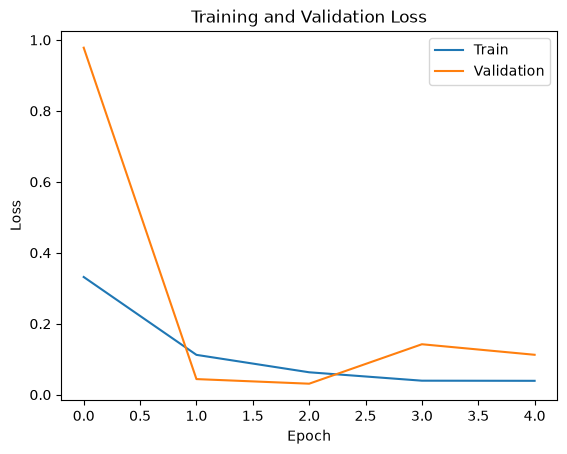

In [18]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

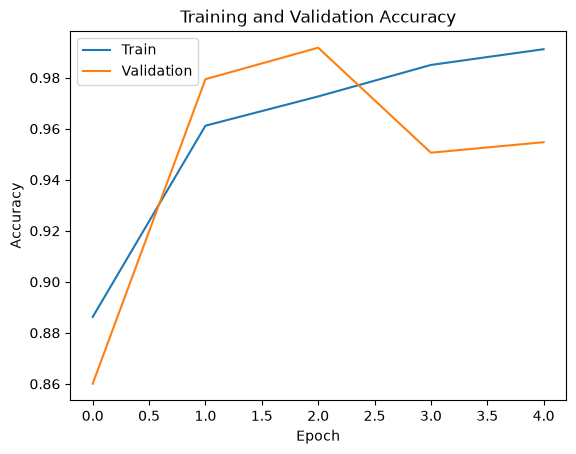

In [19]:
plt.plot(train_accuracies, label="Train")
plt.plot(val_accuracies, label="Validation")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(
            predictions.cpu().numpy()
        )

In [21]:
accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

balanced_accuracy = balanced_accuracy_score(
    true_labels,
    predicted_labels
)

print("Test accuracy:", round(accuracy, 4))
print(
    "Balanced accuracy:",
    round(balanced_accuracy, 4)
)

Test accuracy: 0.9547
Balanced accuracy: 0.9491


In [22]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=[0, 1, 2],
        target_names=class_names,
        zero_division=0
    )
)

               precision    recall  f1-score   support

Surface_Crack       0.99      0.96      0.97       214
      Pinhole       0.74      0.88      0.81        26
 Delamination       1.00      1.00      1.00         3

     accuracy                           0.95       243
    macro avg       0.91      0.95      0.93       243
 weighted avg       0.96      0.95      0.96       243



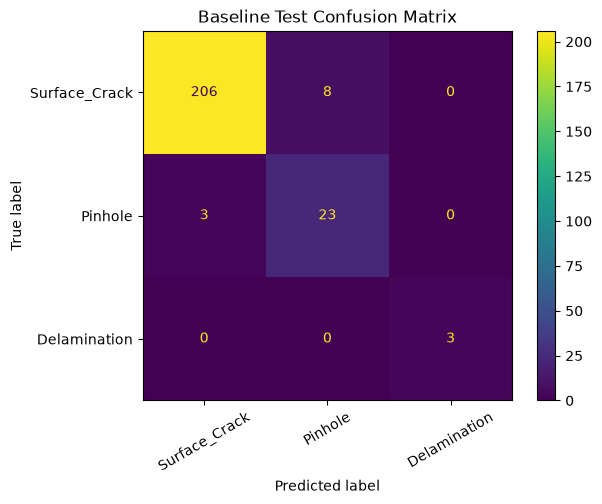

In [23]:
matrix = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2]
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names
)

display_matrix.plot(
    xticks_rotation=30
)

plt.title("Baseline Test Confusion Matrix")
plt.show()

In [24]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "baseline_resnet18.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/Users/kevinnishitoyo/Desktop/Battery Electrode Defect Augmentation/battery-electrode-defect-augmentation/models/baseline_resnet18.pth


## Baseline observations

The baseline model was trained on the original imbalanced dataset without
class weights or synthetic images.

The overall accuracy must be interpreted cautiously because surface cracks
represent most of the dataset. Balanced accuracy, per-class recall, macro F1,
and the confusion matrix provide a more meaningful assessment of performance
on the minority classes.

The next experiment will compare this baseline with an imbalance-handling
method such as class-weighted loss.